### Implement the Model - Decision Tree

### 1. Import the python libraries

In [23]:
import pandas as pd
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import classification_report, confusion_matrix
from imblearn.pipeline import Pipeline 
from imblearn.under_sampling import RandomUnderSampler
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc
from sklearn.metrics import precision_recall_curve, classification_report
from sklearn.metrics import PrecisionRecallDisplay
import joblib
import gc
from sklearn.model_selection import RandomizedSearchCV
from sklearn.base import BaseEstimator, ClassifierMixin
import numpy as np

from scipy.stats import randint, uniform


### 2. Import the data 

In [2]:
train_filepath = '../data/processed/neiss_feature-engineered_train_data.parquet'
eval_filepath = '../data/processed/neiss_feature-engineered_eval_data.parquet'
holdout_filepath =  '../data/processed/neiss_feature-engineered_holdout_data.parquet'

In [3]:
train_data= pd.read_parquet(train_filepath)
eval_data = pd.read_parquet(eval_filepath)
holdout_data = pd.read_parquet(holdout_filepath)

### 3. Setup the train/evaluation dataset

In [4]:
X_train = train_data.drop(columns=['Hospitalized'])
y_train = train_data['Hospitalized']
X_eval = eval_data.drop(columns=['Hospitalized'])
y_eval = eval_data['Hospitalized']

### 4. Run Decision Tree with Majority Undersampling technique

In [5]:
print("Initializing Decision Tree Pipeline...")

# Define the undersampler
rus = RandomUnderSampler(sampling_strategy='majority', random_state=42)

# Initialize the decisoin tree algorithm
decision_tree = DecisionTreeClassifier(
        max_depth=10, 
        min_samples_leaf=50, 
        random_state=42
    )

# Build the pipeline
model_pipeline = Pipeline(steps=[
        ('undersampler', rus),
        ('classifier', decision_tree)
    ])

print("Training model (undersampling majority class)...")
# Fit the model on train dataset
model_pipeline.fit(X_train, y_train)


Initializing Decision Tree Pipeline...
Training model (undersampling majority class)...


,steps,"[('undersampler', ...), ('classifier', ...)]"
,transform_input,None
,memory,None
,verbose,False
,sampling_strategy,'majority'
,random_state,42
,replacement,False
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",10
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2


### 5. Evaluate the results

In [6]:
print("\nEvaluating on Validation (Eval) Set...")
y_pred = model_pipeline.predict(X_eval)

# Print the Results
print("\n--- Confusion Matrix ---")
print(confusion_matrix(y_eval, y_pred))

print("\n--- Classification Report ---")
print(classification_report(y_eval, y_pred))


Evaluating on Validation (Eval) Set...

--- Confusion Matrix ---
[[784938 212581]
 [ 18314  81411]]

--- Classification Report ---
              precision    recall  f1-score   support

           0       0.98      0.79      0.87    997519
           1       0.28      0.82      0.41     99725

    accuracy                           0.79   1097244
   macro avg       0.63      0.80      0.64   1097244
weighted avg       0.91      0.79      0.83   1097244



### Low F1 score of 0.41 similar to the baseline model but the model is able to predict the minority class (recall = 0.42). The model is however having a low precision score (0.28) leading to high false positives.

### 6. Draw RUC-AUC Curve

Generating Final ROC-AUC Curve for Decision Tree...


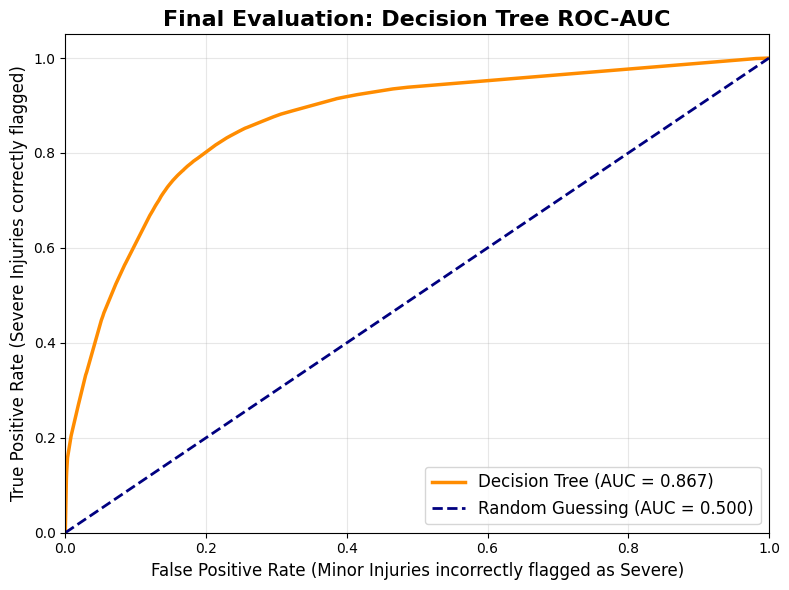

In [8]:


def plot_single_roc(model_pipeline, X_test, y_test, model_name="Final Champion Model"):
    """
    Calculates probabilities and plots the ROC-AUC curve for a single trained model 
    against the Hold-Out Test dataset.
    """
    print(f"Generating Final ROC-AUC Curve for {model_name}...")
    
    # 1. Get the probability that the patient is in the Positive Class (Hospitalized)
    # .predict_proba() returns [Probability_Released, Probability_Hospitalized]
    # We slice [:, 1] to grab only the Hospitalized probabilities.
    y_prob = model_pipeline.predict_proba(X_test)[:, 1]
    
    # 2. Calculate the False Positive Rate (fpr) and True Positive Rate (tpr)
    fpr, tpr, thresholds = roc_curve(y_test, y_prob)
    
    # 3. Calculate the Area Under the Curve (AUC) score
    roc_auc = auc(fpr, tpr)
    
    # 4. Set up the plotting canvas
    plt.figure(figsize=(8, 6))
    
    # 5. Plot the Model's Curve
    # We use a bold color (like dark orange) to make it pop for presentations
    plt.plot(fpr, tpr, color='darkorange', lw=2.5, 
             label=f'{model_name} (AUC = {roc_auc:.3f})')

    # 6. Plot the "Coin Flip" Baseline (Random Guessing)
    plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', 
             label='Random Guessing (AUC = 0.500)')

    # 7. Format the Graph for Professional Presentation
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('False Positive Rate (Minor Injuries incorrectly flagged as Severe)', fontsize=12)
    plt.ylabel('True Positive Rate (Severe Injuries correctly flagged)', fontsize=12)
    plt.title(f'Final Evaluation: {model_name} ROC-AUC', fontsize=16, fontweight='bold')
    plt.legend(loc="lower right", fontsize=12)
    plt.grid(alpha=0.3)
    
    # 8. Display the Graph
    plt.tight_layout()
    plt.show()

plot_single_roc(model_pipeline, X_eval, y_eval, model_name="Decision Tree")

### 7. Drawing PR-AUC 

Generating PR-AUC Curve...


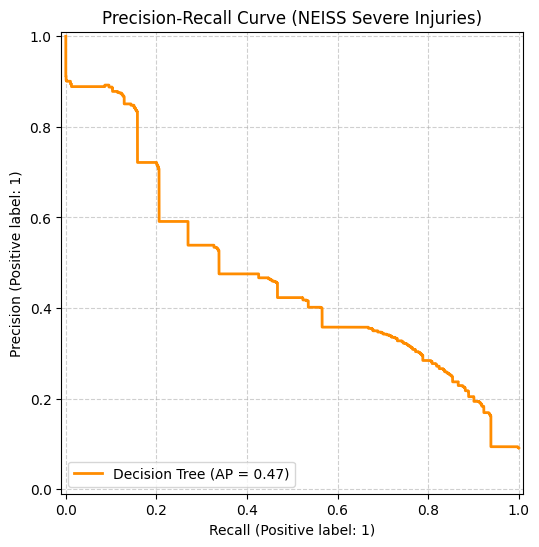

In [17]:
def plot_quick_pr_curve(model, X_test, y_test):
    """
    Draws a standard PR-AUC curve using scikit-learn's built-in display API.
    """
    print("Generating PR-AUC Curve...")
    
    # 1. Set up the plot size
    fig, ax = plt.subplots(figsize=(8, 6))
    
    # 2. Use the built-in Display function
    # It automatically calculates probabilities and plots the curve
    display = PrecisionRecallDisplay.from_estimator(
        estimator=model,
        X=X_test,
        y=y_test,
        name="Decision Tree",
        ax=ax,
        color='darkorange',
        linewidth=2
    )
    
    # 3. Add styling
    ax.set_title("Precision-Recall Curve (NEISS Severe Injuries)")
    ax.grid(True, linestyle='--', alpha=0.6)
    plt.show()

# Usage:
plot_quick_pr_curve(model_pipeline, X_eval, y_eval)

### 8. Hyperparameter Tuning

In [16]:
# 1. Define the base model
decision_tree = DecisionTreeClassifier(random_state=42)

# 2. Define the hyperparameter distribution
# These ranges encourage the tree to generalize rather than overfit
param_distributions = {
    'max_depth': [5, 10,15,20],
    '   ': [50, 100],
    'min_samples_leaf': [25, 50,100],
    'criterion': ['gini', 'entropy'],
    
    # Note: If you are already applying a resampling technique like SMOTE 
    # upstream in your pipeline, keep this as [None]. If you are feeding 
    # the raw imbalanced data, include 'balanced'.
    'class_weight': [None, 'balanced'] 
}

# 3. Configure the RandomizedSearchCV
random_search = RandomizedSearchCV(
    estimator=decision_tree,
    param_distributions=param_distributions,
    n_iter=10,               # Tests 30 random combinations from the grid
    scoring='f1',            # Directly optimizes for F1-score
    cv=3,                    # 5-fold cross-validation to ensure robustness
    n_jobs=-1,               # Uses all available CPU cores to speed up training
    random_state=42,
    verbose=2                # Prints progress updates to the console
)

# 4. Execute the search
# (Assuming X_train and y_train are your preprocessed training data)
print("Starting hyperparameter tuning...")
random_search.fit(X_train, y_train)

# 5. Extract and evaluate the optimal model
best_dt_model = random_search.best_estimator_

print("\n--- Tuning Complete ---")
print("Best Hyperparameters Found:", random_search.best_params_)

# 6. Generate predictions using the unseen test data
y_pred_optimized = best_dt_model.predict(X_eval)

# 7. Print the new metrics
print("\n--- Optimized Classification Report ---")
print(classification_report(y_eval, y_pred_optimized))

Starting hyperparameter tuning...
Fitting 3 folds for each of 10 candidates, totalling 30 fits
[CV] END class_weight=balanced, criterion=entropy, max_depth=5, min_samples_leaf=25, min_samples_split=100; total time= 1.2min
[CV] END class_weight=balanced, criterion=entropy, max_depth=5, min_samples_leaf=100, min_samples_split=100; total time= 1.2min
[CV] END class_weight=balanced, criterion=entropy, max_depth=5, min_samples_leaf=100, min_samples_split=100; total time= 1.2min
[CV] END class_weight=balanced, criterion=entropy, max_depth=5, min_samples_leaf=25, min_samples_split=100; total time= 1.2min
[CV] END class_weight=balanced, criterion=entropy, max_depth=5, min_samples_leaf=25, min_samples_split=100; total time= 1.2min
[CV] END class_weight=balanced, criterion=entropy, max_depth=5, min_samples_leaf=100, min_samples_split=100; total time= 1.2min
[CV] END class_weight=balanced, criterion=entropy, max_depth=10, min_samples_leaf=50, min_samples_split=50; total time= 5.7min
[CV] END clas

### The new optimized tree manages to obtain an F1 score of 0.43.

### 9. Plot PR-AUC Curve

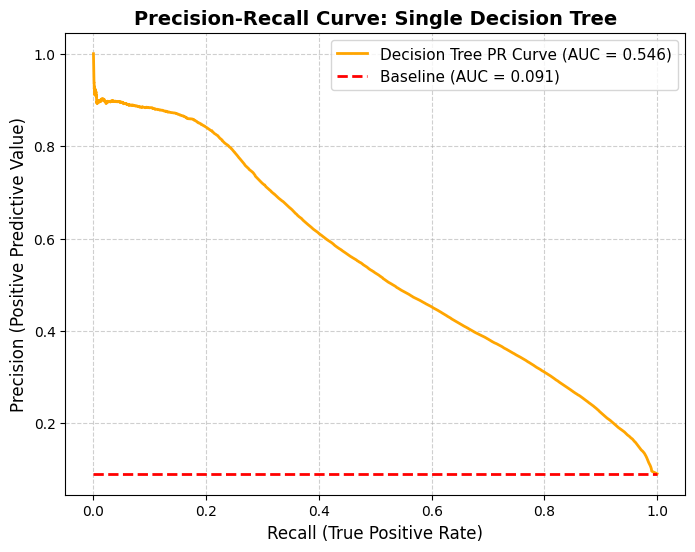

In [20]:

# 1. Extract the raw probabilities for Class 1 from your Decision Tree
# (Ensure your trained decision tree is named 'dt_model')
y_probs_dt = best_dt_model.predict_proba(X_eval)[:, 1]

# 2. Calculate Precision, Recall, and thresholds
precision_dt, recall_dt, thresholds_dt = precision_recall_curve(y_eval, y_probs_dt)

# 3. Calculate the Area Under the Curve (PR-AUC)
pr_auc_dt = auc(recall_dt, precision_dt)

# 4. Set up the plot
plt.figure(figsize=(8, 6))

# Plot the Decision Tree curve
plt.plot(recall_dt, precision_dt, color='orange', lw=2, 
         label=f'Decision Tree PR Curve (AUC = {pr_auc_dt:.3f})')

# Plot the baseline (random guessing prevalence)
baseline = len(y_eval[y_eval== 1]) / len(y_eval)
plt.plot([0, 1], [baseline, baseline], color='red', linestyle='--', 
         lw=2, label=f'Baseline (AUC = {baseline:.3f})')

# 5. Format the chart for your report
plt.title('Precision-Recall Curve: Single Decision Tree', fontsize=14, fontweight='bold')
plt.xlabel('Recall (True Positive Rate)', fontsize=12)
plt.ylabel('Precision (Positive Predictive Value)', fontsize=12)
plt.legend(loc='upper right', fontsize=11)
plt.grid(True, linestyle='--', alpha=0.6)

# Save the plot to drop into your CRISP-DM document
plt.savefig('decision_tree_pr_curve.png', dpi=300, bbox_inches='tight')
plt.show()

### An Interesting observation - Even though the F1 score is low (0.43) the PR-AUC score is high 0.546. The F1 score of 0.43 is calculated at one exact probability cutoff (the default 0.50). It judges the model's performance exactly at that single point. The PR-AUC of 0.54 is the aggregate score of every possible cutoff (from 0.00 to 1.00). It judges the model's overall capability to separate the classes, regardless of which specific cutoff we choose. Which could mean that we could alter the default tresholds to create a more optimal decision tree.

### 10. Identifing the correc threshold by tuning the hyperparametrs and then obtaining the best model

In [22]:

# 1. Define the blueprint FIRST class 
class CustomThresholdClassifier(BaseEstimator, ClassifierMixin):
    def __init__(self, estimator, threshold=0.50):
        self.estimator = estimator
        self.threshold = threshold

    def fit(self, X, y, **fit_params):
        self.estimator.fit(X, y, **fit_params)
        self.classes_ = self.estimator.classes_
        return self

    def predict(self, X):
        probabilities = self.estimator.predict_proba(X)[:, 1]
        return (probabilities >= self.threshold).astype(int)

    def predict_proba(self, X):
        return self.estimator.predict_proba(X)

In [26]:

# 1. Initialize the base model and wrap it in your custom class
base_tree = DecisionTreeClassifier(random_state=42)
custom_clf = CustomThresholdClassifier(estimator=base_tree)

# 2. Define the hyperparameter grid
# CRITICAL: Use 'estimator__' for the Decision Tree parameters
# Use 'threshold' directly for your custom wrapper parameter
param_dist = {
    'estimator__max_depth': randint(3, 20),
    'estimator__min_samples_split': randint(2, 20),
    'estimator__min_samples_leaf': randint(1, 20),
    'estimator__criterion': ['gini', 'entropy'],
    
    # Now the search will also test different thresholds simultaneously!
    'threshold': uniform(0.1, 0.8) # Tests thresholds between 0.10 and 0.90
}

# 3. Set up the RandomizedSearchCV
# Because the wrapper handles the threshold, scoring='f1' will now 
# calculate the score based on the tested threshold, NOT 0.50.
random_search = RandomizedSearchCV(
    estimator=custom_clf,
    param_distributions=param_dist,
    n_iter=10,             # Number of combinations to try
    scoring='f1',          # Optimizing for F1-Score
    cv=3,                  # 5-fold cross-validation
    n_jobs=-1,             # Use all CPU cores
    random_state=42,
    verbose=1
)

# 4. Execute the search on your training data
print("Starting simultaneous threshold and architecture tuning...")
random_search.fit(X_train, y_train)

# 5. Extract the absolute best combination
print(f"Best F1 Score achieved: {random_search.best_score_:.4f}")
print("Best parameters found:")
for param, value in random_search.best_params_.items():
    print(f" - {param}: {value}")

# 6. Save the winning model (which already includes the optimal threshold)
best_optimized_tree = random_search.best_estimator_

Starting simultaneous threshold and architecture tuning...
Fitting 3 folds for each of 10 candidates, totalling 30 fits
Best F1 Score achieved: 0.5087
Best parameters found:
 - estimator__criterion: gini
 - estimator__max_depth: 13
 - estimator__min_samples_leaf: 11
 - estimator__min_samples_split: 5
 - threshold: 0.21429345433755265


### 7. Export the models

In [27]:
print("Exporting Decison Tree pipeline to disk...")
model_path = '../models/neiss_decision_tree.joblib'
joblib.dump(best_optimized_tree, model_path)
print("Model successfully saved!")

Exporting Decison Tree pipeline to disk...
Model successfully saved!


In [9]:
n = gc.collect()
print(f"Number of unreachable objects collected: {n}")

Number of unreachable objects collected: 3220
